# Notebook 1 - Explanatory data analysis (EDA)
### Matej Magat, 0036541718

## Dimensionality of the dataset

In [1]:
from calendar import month

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm_pandas

In [4]:
dataset = pd.read_csv("/kaggle/input/dap-fer2025/dataset.csv")
dataset.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Contactless,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0.0,...,437.63,3.0,Amex,65.0,883.17,Biometric,0.8494,NaN,0.0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0.0,...,478.76,4.0,Mastercard,186.0,2203.36,Password,0.0959,NaN,0.0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0.0,...,50.01,4.0,Visa,226.0,1909.29,Biometric,0.8400,NaN,0.0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0.0,...,182.48,4.0,Visa,76.0,1311.86,OTP,0.7935,NaN,0.0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0.0,...,328.69,4.0,Mastercard,140.0,966.98,Password,0.3819,NaN,1.0,1


In [5]:
n_samples = dataset.shape[0]
n_features = dataset.shape[1]
unique_users = dataset["User_ID"].unique()
print("Dataset contains: ")
print(f"\t{n_samples} samples")
print(f"\t{n_features} features")
print(f"There are {len(unique_users)} unique users")

Dataset contains: 
	50012 samples
	22 features
There are 8964 unique users


## Missing values

In [6]:
for feature in dataset.columns:
    print(f"\t{feature}: {dataset[feature].isna().sum()}")

	Transaction_ID: 0
	User_ID: 0
	Transaction_Amount: 9
	Transaction_Type: 9
	Timestamp: 0
	Account_Balance: 9
	Device_Type: 9
	Location: 9
	Merchant_Category: 9
	IP_Address_Flag: 9
	Previous_Fraudulent_Activity: 9
	Daily_Transaction_Count: 9
	Avg_Transaction_Amount_7d: 9
	Failed_Transaction_Count_7d: 9
	Card_Type: 9
	Card_Age: 9
	Transaction_Distance: 9
	Authentication_Method: 9
	Risk_Score: 9
	Is_Contactless: 49012
	Is_Weekend: 9
	Fraud_Label: 0


Most features have exactly 9 missing values due to each transaction for USER_007 being empty. Removing USER_007 solves the problem. 

In [7]:
filtered_dataset = dataset[dataset["User_ID"] == "USER_0007"]
for feature in filtered_dataset.columns:
    print(f"\t{feature}: {filtered_dataset[feature].isna().sum()}")

	Transaction_ID: 0
	User_ID: 0
	Transaction_Amount: 9
	Transaction_Type: 9
	Timestamp: 0
	Account_Balance: 9
	Device_Type: 9
	Location: 9
	Merchant_Category: 9
	IP_Address_Flag: 9
	Previous_Fraudulent_Activity: 9
	Daily_Transaction_Count: 9
	Avg_Transaction_Amount_7d: 9
	Failed_Transaction_Count_7d: 9
	Card_Type: 9
	Card_Age: 9
	Transaction_Distance: 9
	Authentication_Method: 9
	Risk_Score: 9
	Is_Contactless: 9
	Is_Weekend: 9
	Fraud_Label: 0


In [8]:
dataset = dataset[dataset["User_ID"] != "USER_0007"]
for feature in dataset.columns:
    print(f"\t{feature}: {dataset[feature].isna().sum()}")

	Transaction_ID: 0
	User_ID: 0
	Transaction_Amount: 0
	Transaction_Type: 0
	Timestamp: 0
	Account_Balance: 0
	Device_Type: 0
	Location: 0
	Merchant_Category: 0
	IP_Address_Flag: 0
	Previous_Fraudulent_Activity: 0
	Daily_Transaction_Count: 0
	Avg_Transaction_Amount_7d: 0
	Failed_Transaction_Count_7d: 0
	Card_Type: 0
	Card_Age: 0
	Transaction_Distance: 0
	Authentication_Method: 0
	Risk_Score: 0
	Is_Contactless: 49003
	Is_Weekend: 0
	Fraud_Label: 0


In [10]:
percent_of_nan = dataset["Is_Contactless"].isna().sum()/n_samples * 100
print(f"{percent_of_nan:.2f}%")
print(dataset["Is_Contactless"].unique())
print(dataset["Transaction_Type"].unique())

97.98%
[nan True]
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']


Feature Is_Contactless has 97.98% missing values.

There are three options:
- remove the feature
- infer its value from other features (Transaction_Type)
- conclude that nan is actually False and not a missing value

Transaction_Type can't be used to infer Is_Contactless because POS could potentially include contactless transactions, but it's not guaranteed. Other values of Transaction_Type are generally not contactless transactions.

While it might be tempting to interpret the 'nan' values as 'False' given the presence of only 'True' values in the dataset, we should exercise caution in making such an assumption. The fact that 97.98% of the data points are missing is a significant concern.

Making an assumption about such a large portion of the dataset could potentially introduce substantial bias into our predictions.

It is best to just remove the feature.

    


In [11]:
dataset = dataset.drop(columns=["Is_Contactless"])

In [12]:
for feature in dataset.columns:
    print(f"\t{feature}: {dataset[feature].isna().sum()}")

	Transaction_ID: 0
	User_ID: 0
	Transaction_Amount: 0
	Transaction_Type: 0
	Timestamp: 0
	Account_Balance: 0
	Device_Type: 0
	Location: 0
	Merchant_Category: 0
	IP_Address_Flag: 0
	Previous_Fraudulent_Activity: 0
	Daily_Transaction_Count: 0
	Avg_Transaction_Amount_7d: 0
	Failed_Transaction_Count_7d: 0
	Card_Type: 0
	Card_Age: 0
	Transaction_Distance: 0
	Authentication_Method: 0
	Risk_Score: 0
	Is_Weekend: 0
	Fraud_Label: 0


## Duplicates 

In [13]:
print(f"Dataset size before removing duplicates: {len(dataset)}")
dataset_temp = dataset.drop_duplicates(subset=dataset.columns[0], keep=False)
print(f"Dataset size after removing duplicates: {len(dataset_temp)}")

Dataset size before removing duplicates: 50003
Dataset size after removing duplicates: 50003


There are no duplicates.

## Data validation

In [14]:
def check_numeric(dataset, feature):
    print(feature)
    print(f"min: {dataset[feature].min()}")
    print(f"max: {dataset[feature].max()}")
    print()

def check_categorical(dataset, feature):
    print(feature)
    print(dataset[feature].unique())
    print()
    
numeric_to_check = ["Transaction_Amount", "Account_Balance", "Daily_Transaction_Count", "Avg_Transaction_Amount_7d", "Failed_Transaction_Count_7d", "Card_Age", "Transaction_Distance", "Risk_Score",]
categorical_to_check = ["Transaction_Type", "Device_Type", "Location", "Merchant_Category", "IP_Address_Flag", "Previous_Fraudulent_Activity", "Card_Type", "Authentication_Method",  "Is_Weekend", "Fraud_Label"]

for feature in numeric_to_check:
    check_numeric(dataset, feature)
for feature in categorical_to_check:
    check_categorical(dataset, feature)

Transaction_Amount
min: -200.35
max: 1174.14

Account_Balance
min: 500.48
max: 99998.31

Daily_Transaction_Count
min: 1.0
max: 14.0

Avg_Transaction_Amount_7d
min: 10.0
max: 500.0

Failed_Transaction_Count_7d
min: 0.0
max: 4.0

Card_Age
min: 1.0
max: 239.0

Transaction_Distance
min: 0.25
max: 4999.93

Risk_Score
min: 0.0001
max: 1.0

Transaction_Type
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']

Device_Type
['Laptop' 'Mobile' 'Tablet']

Location
['Sydney' 'New York' 'Mumbai' 'Tokyo' 'London' 'Lndn']

Merchant_Category
['Travel' 'Clothing' 'Restaurants' 'Electronics' 'Groceries' 'Electronis']

IP_Address_Flag
[0. 1.]

Previous_Fraudulent_Activity
[0. 1.]

Card_Type
['Amex' 'Mastercard' 'Visa' 'Discover']

Authentication_Method
['Biometric' 'Password' 'OTP' 'PIN']

Is_Weekend
[0. 1.]

Fraud_Label
[0 1]



Dataset contains three mistakes:
- there are three negative transactions (all made by the same user)
- Location Lndn is abbreviated name for London
- Merchant_Category has a typo "Electronis"

In [15]:
dataset = dataset[dataset["Transaction_Amount"] >= 0]
dataset = dataset.replace({"Location": {"Lndn": "London"}})
dataset = dataset.replace({"Merchant_Category": {"Electronis": "Electronics"}})

In [16]:
for feature in numeric_to_check:
    check_numeric(dataset, feature)
for feature in categorical_to_check:
    check_categorical(dataset, feature)

Transaction_Amount
min: 0.0
max: 1174.14

Account_Balance
min: 500.48
max: 99998.31

Daily_Transaction_Count
min: 1.0
max: 14.0

Avg_Transaction_Amount_7d
min: 10.0
max: 500.0

Failed_Transaction_Count_7d
min: 0.0
max: 4.0

Card_Age
min: 1.0
max: 239.0

Transaction_Distance
min: 0.25
max: 4999.93

Risk_Score
min: 0.0001
max: 1.0

Transaction_Type
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']

Device_Type
['Laptop' 'Mobile' 'Tablet']

Location
['Sydney' 'New York' 'Mumbai' 'Tokyo' 'London']

Merchant_Category
['Travel' 'Clothing' 'Restaurants' 'Electronics' 'Groceries']

IP_Address_Flag
[0. 1.]

Previous_Fraudulent_Activity
[0. 1.]

Card_Type
['Amex' 'Mastercard' 'Visa' 'Discover']

Authentication_Method
['Biometric' 'Password' 'OTP' 'PIN']

Is_Weekend
[0. 1.]

Fraud_Label
[0 1]



Negative transactions are removed and typos are replaced

In [20]:
card_age = dataset["Card_Age"]
print(f"Percentage of samples with cards older than 3 years: {(card_age > 3*12).sum() / n_samples * 100:.2f}%")
print(f"Percentage of samples with cards older than 5 years: {(card_age > 5*12).sum() / n_samples * 100:.2f}%")
print(f"Card age: [{card_age.min()}, {card_age.max()}]")

Percentage of samples with cards older than 3 years: 84.90%
Percentage of samples with cards older than 5 years: 74.85%
Card age: [1.0, 239.0]


Usually, maximum age for a card is 3 or 5 years. However, there are too many "old" cards so it is hard to decide what to do.

In [21]:
on_weekend = dataset[dataset["Is_Weekend"] == 1]["Timestamp"]
not_on_weekend = dataset[dataset["Is_Weekend"] != 1]["Timestamp"]

In [22]:
from datetime import datetime

count = 0
for timestamp in on_weekend:
    year, month, day = timestamp.split(" ")[0].split("-")
    if datetime(year=int(year), month=int(month), day=int(day)).isoweekday() <= 5:
        count += 1
        
for timestamp in not_on_weekend:
    year, month, day = timestamp.split(" ")[0].split("-")
    if datetime(year=int(year), month=int(month), day=int(day)).isoweekday() > 5:
        count += 1
        
print(f"{count / len(dataset) * 100:.2f}% of samples have wrong Is_Weekend flag")

41.51% of samples have wrong Is_Weekend flag


Is_Weekend flag needs to be replaced with correct values.

In [23]:
fixed = 0
for index, row in dataset.iterrows():
    timestamp = row["Timestamp"]
    year, month, day = timestamp.split(" ")[0].split("-")
    new_value = 0
    if datetime(year=int(year), month=int(month), day=int(day)).isoweekday() > 5:
        new_value = 1
    if row["Is_Weekend"] != new_value:
        fixed += 1
    dataset.at[index, "Is_Weekend"] = new_value
print(f"{fixed/len(dataset) * 100:.2f}%")

41.51%


## Feature distributions

In [24]:
def plot_distribution_numeric(df, feature, bins=30, figsize=(10, 6)):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.15, 0.85)},
        figsize=figsize
    )
    
    fig.suptitle(f'Distribution of {feature}', fontsize=14, y=0.93)
    
    sns.boxplot(data=df, x=feature, ax=ax_box, color='skyblue')
    ax_box.set(xlabel='')  # Remove x-axis label for boxplot
    
    sns.histplot(data=df, x=feature, bins=bins, ax=ax_hist, kde=True, color='teal')
    ax_hist.set(ylabel='Frequency')
    
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    ax_hist.axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='g', linestyle='-', label=f'Median: {median_val:.2f}')
    ax_hist.legend()
    
    plt.tight_layout()
    plt.show()


def plot_distribution_categorical(df, feature, figsize=(12, 6)):
    fig, (ax_pie, ax_bar) = plt.subplots(ncols=2, figsize=figsize)
    
    fig.suptitle(f'Distribution of {feature}', fontsize=16, y=1.02)
    
    value_counts = df[feature].value_counts()
    percentages = df[feature].value_counts(normalize=True) * 100
    
    ax_pie.pie(percentages, labels=percentages.index, autopct='%1.1f%%', startangle=90)
    ax_pie.set_title('Pie Chart')
    
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax_bar)
    ax_bar.set_title('Bar Plot')
    ax_bar.set_xlabel(feature)
    ax_bar.set_ylabel('Count')

    if len(value_counts) > 5:
        plt.setp(ax_bar.get_xticklabels(), rotation=45, ha='right')
    
    for i, v in enumerate(value_counts.values):
        ax_bar.text(i, v, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

### Transaction_Amount

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


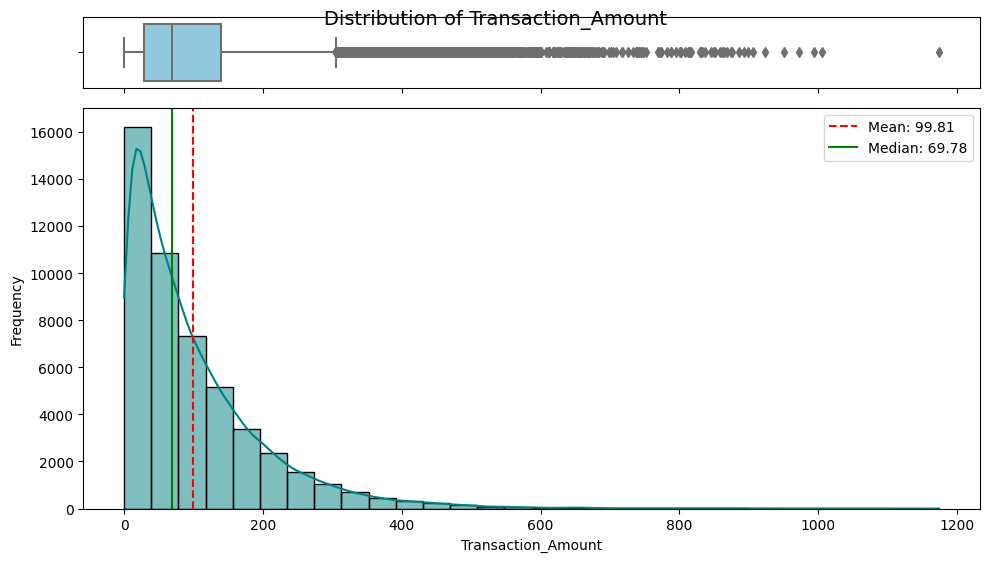

In [25]:
plot_distribution_numeric(dataset, "Transaction_Amount")

### Transaction_Type

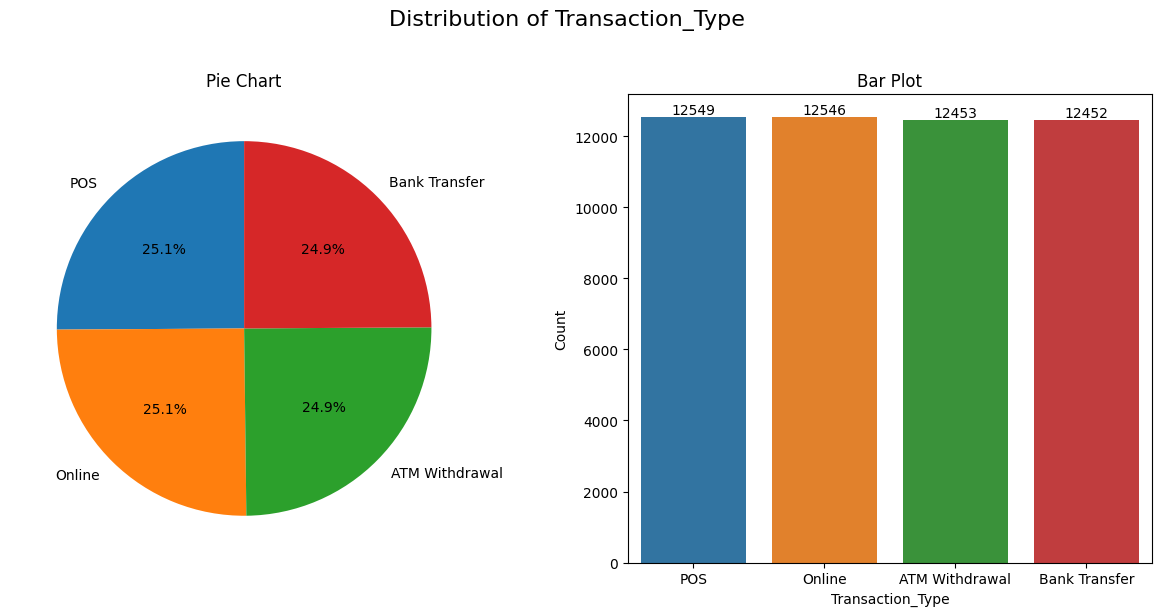

In [26]:
plot_distribution_categorical(dataset, "Transaction_Type")

### Account_Balance

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


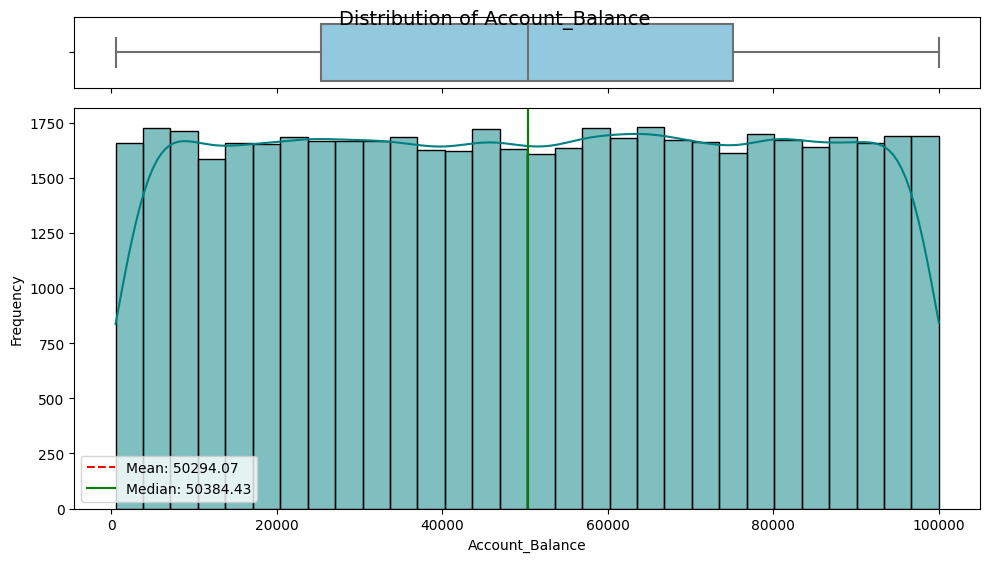

In [27]:
plot_distribution_numeric(dataset, "Account_Balance")

### Device_Type

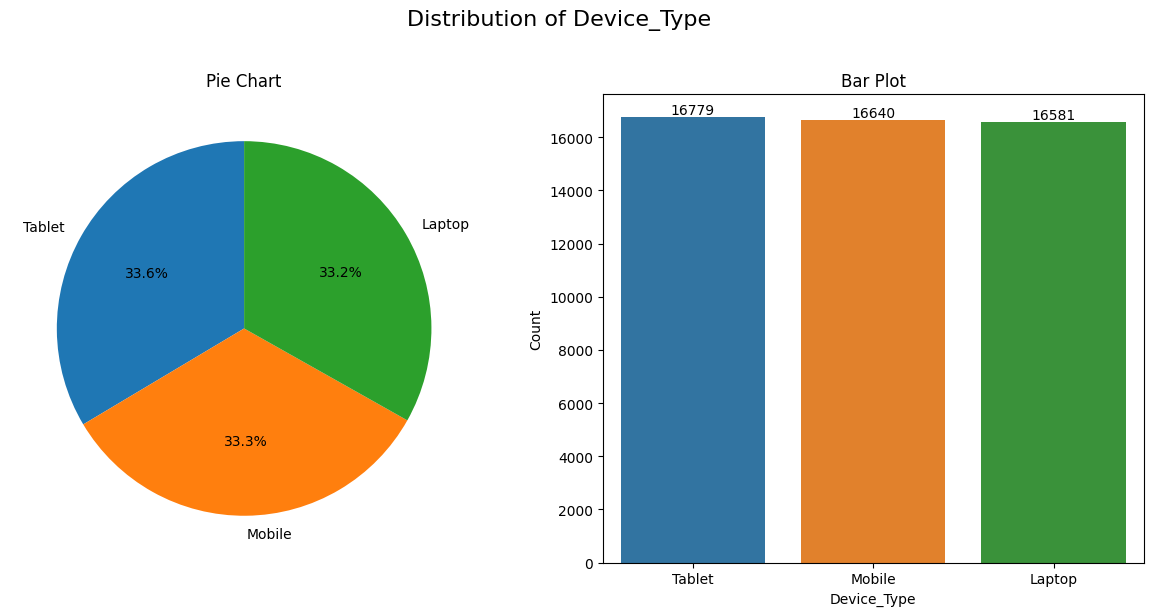

In [28]:
plot_distribution_categorical(dataset, "Device_Type")

### Location

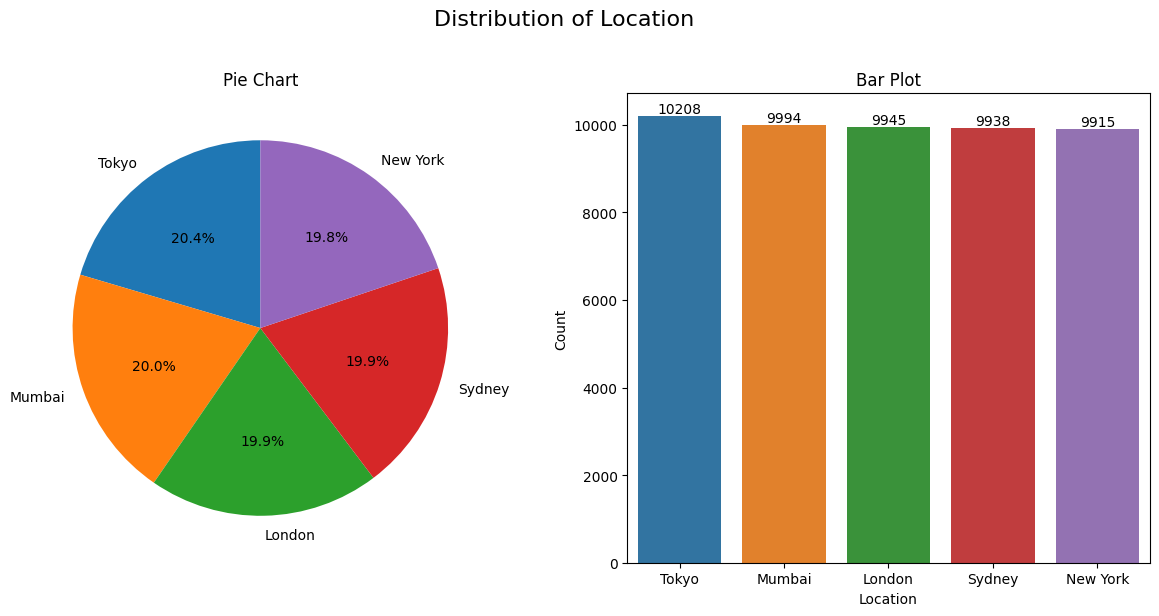

In [29]:
plot_distribution_categorical(dataset, "Location")

### Merchant_Category

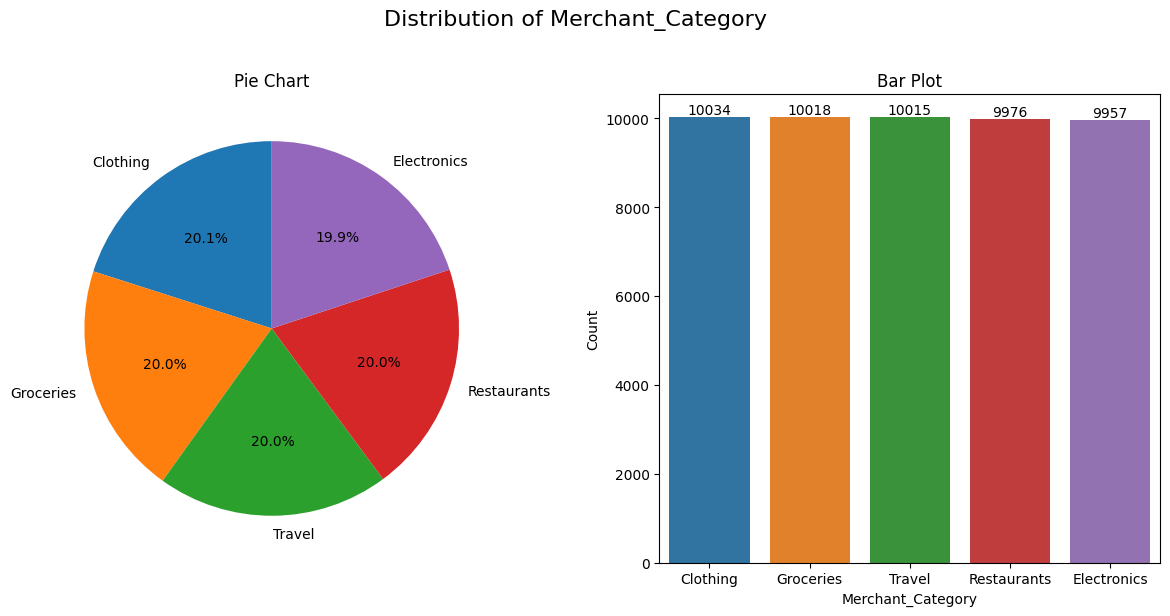

In [30]:
plot_distribution_categorical(dataset, "Merchant_Category")

### IP_Address_Flag

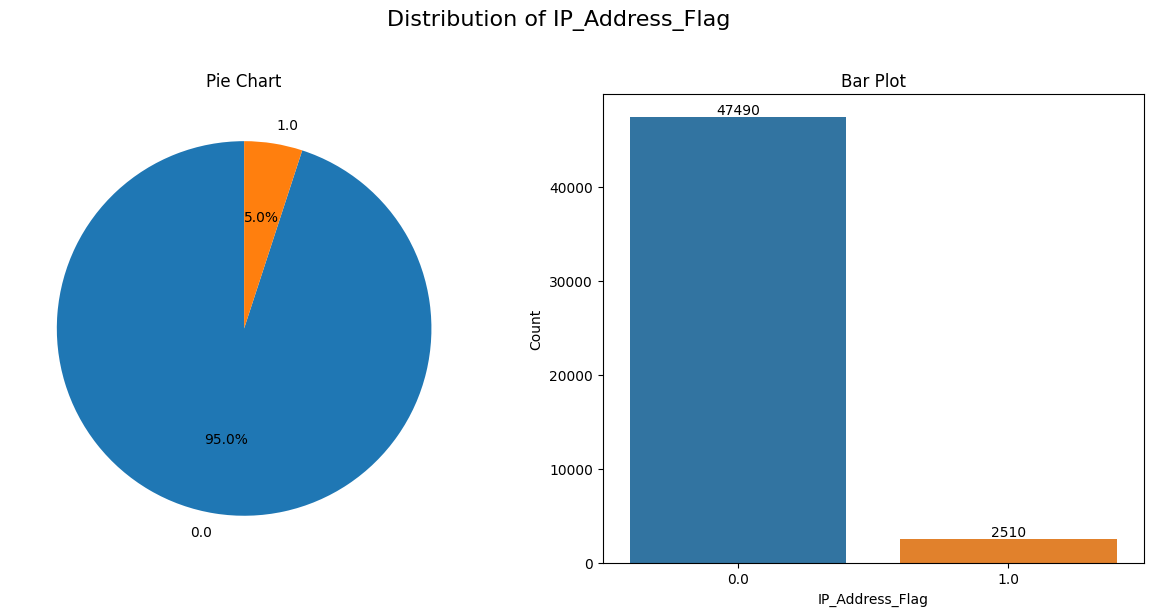

In [31]:
plot_distribution_categorical(dataset, "IP_Address_Flag")

### Previous_Fraudulent_Activity

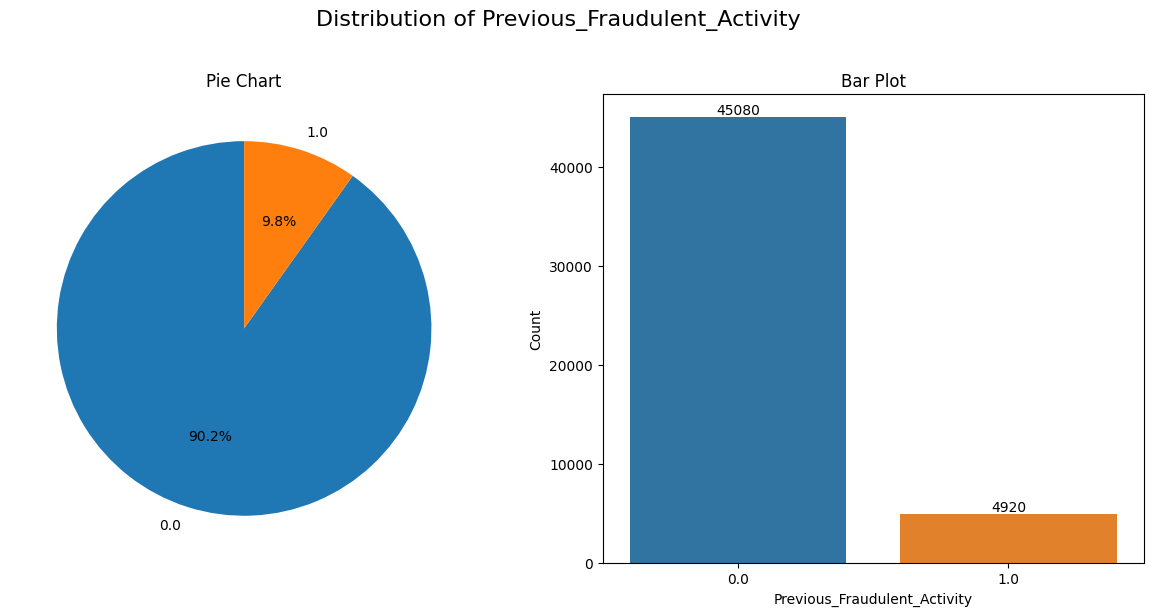

In [32]:
plot_distribution_categorical(dataset, "Previous_Fraudulent_Activity")

### Daily_Transaction_Count

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


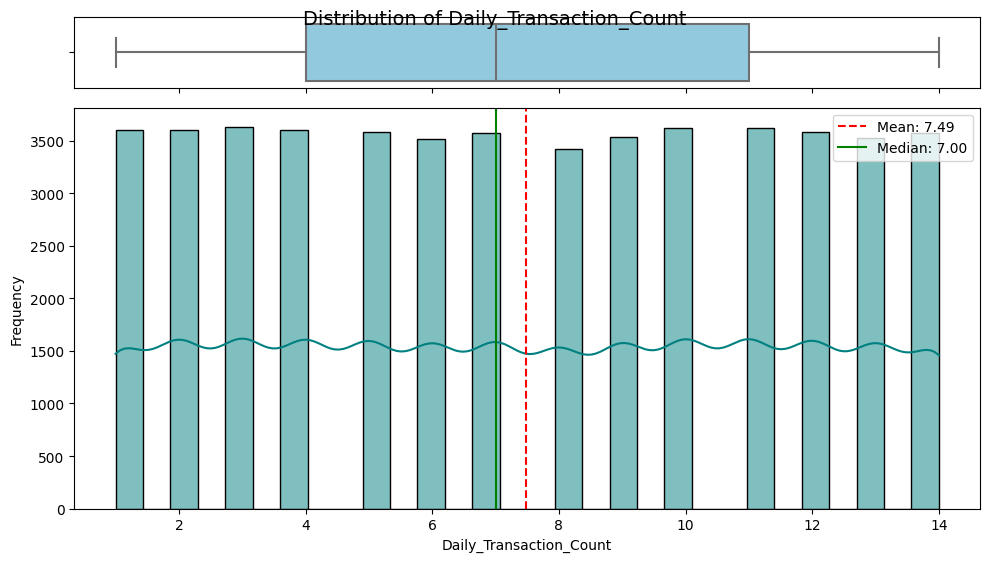

In [33]:
plot_distribution_numeric(dataset, "Daily_Transaction_Count")

### Avg_Transaction_Amount_7d

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


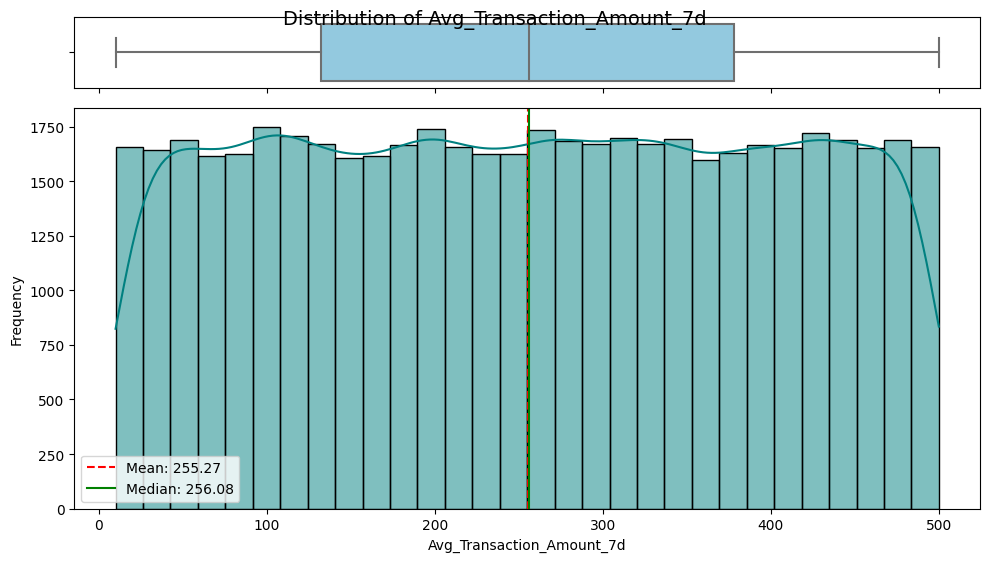

In [34]:
plot_distribution_numeric(dataset, "Avg_Transaction_Amount_7d")

### Failed_Transaction_Count_7d

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


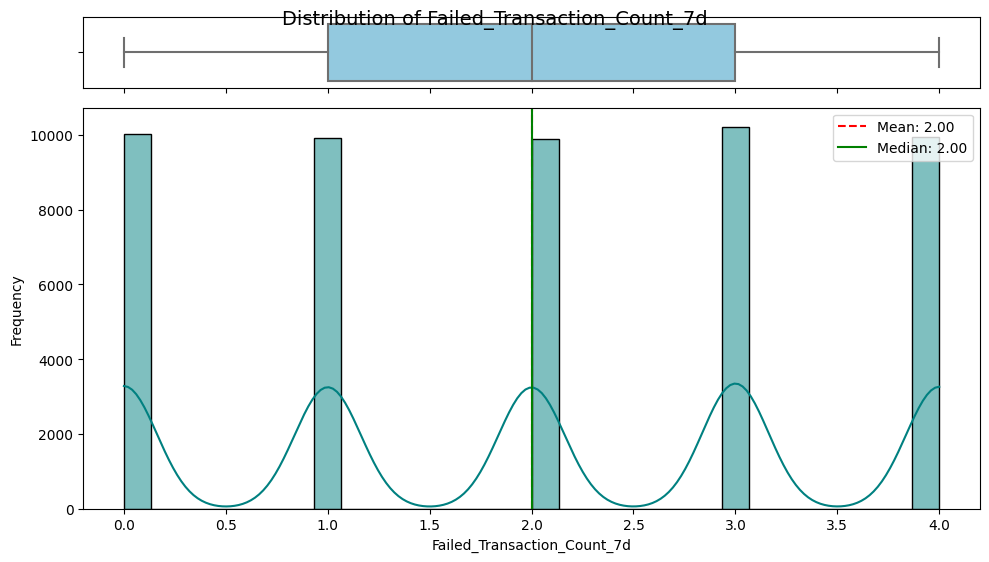

In [35]:
plot_distribution_numeric(dataset, "Failed_Transaction_Count_7d")

### Card_Type

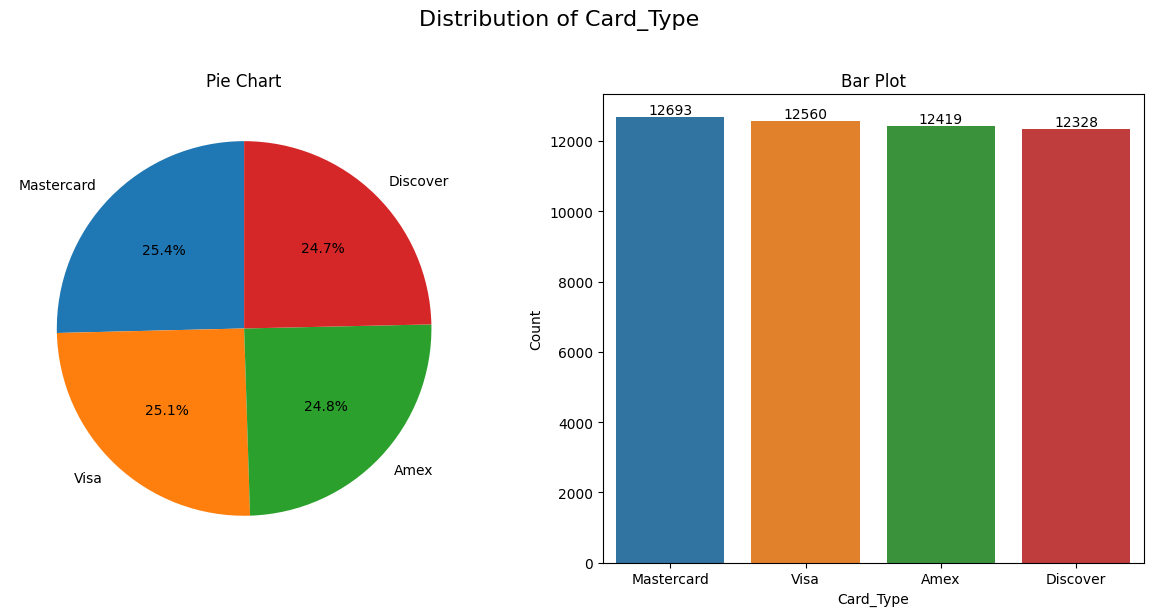

In [36]:
plot_distribution_categorical(dataset, "Card_Type")

### Card_Age

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


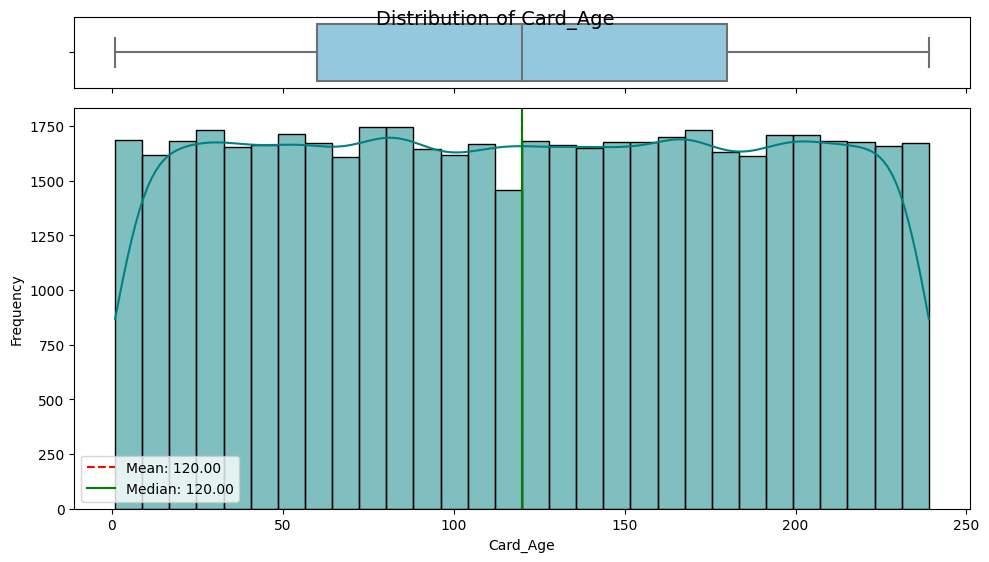

In [37]:
plot_distribution_numeric(dataset, "Card_Age")

### Transaction_Distance

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


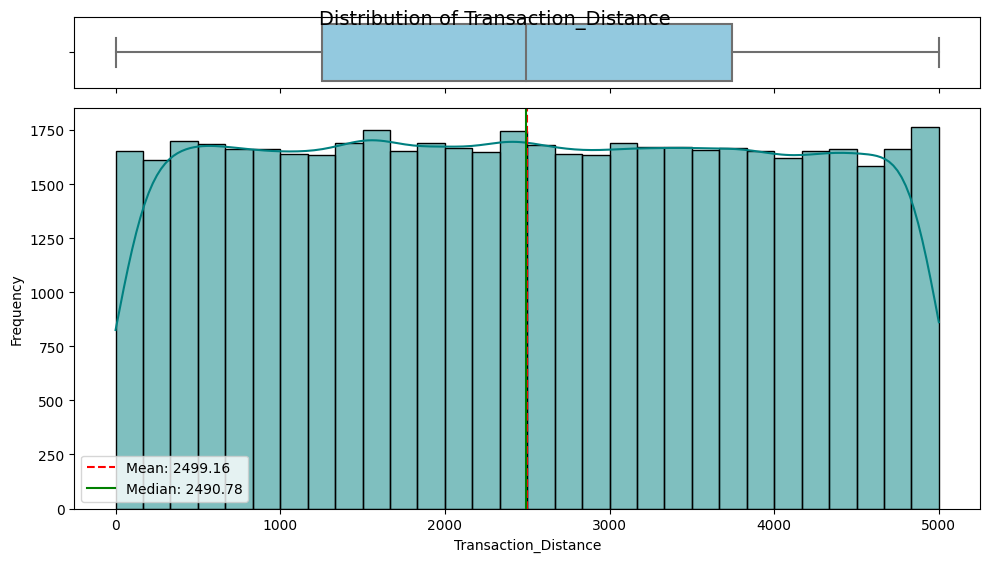

In [38]:
plot_distribution_numeric(dataset, "Transaction_Distance")

### Authentication_Method

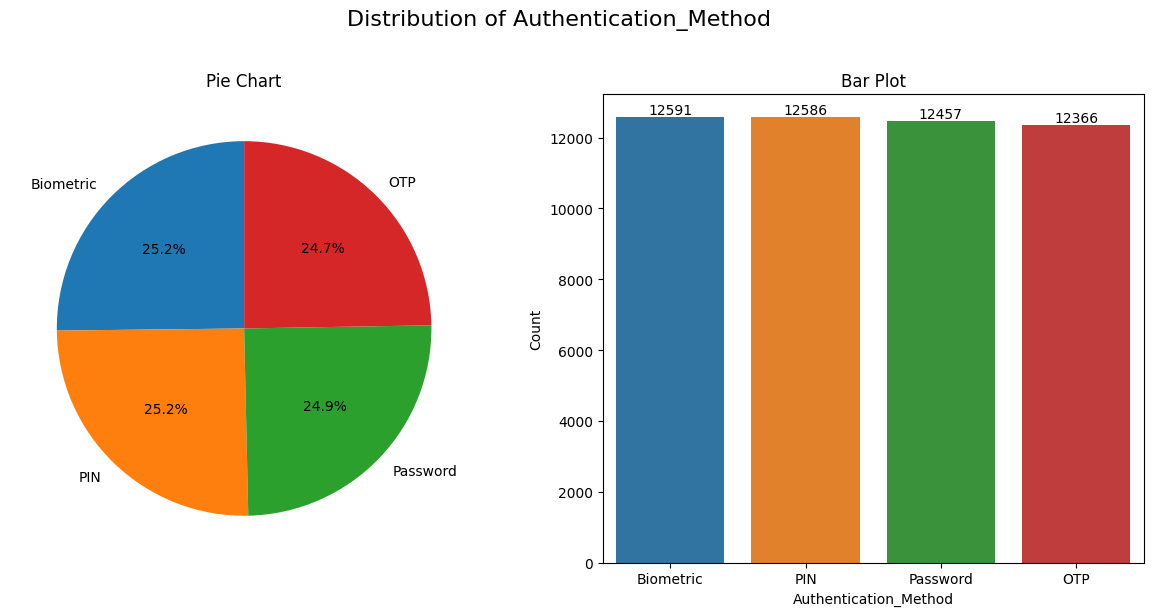

In [39]:
plot_distribution_categorical(dataset, "Authentication_Method")

### Risk_Score

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


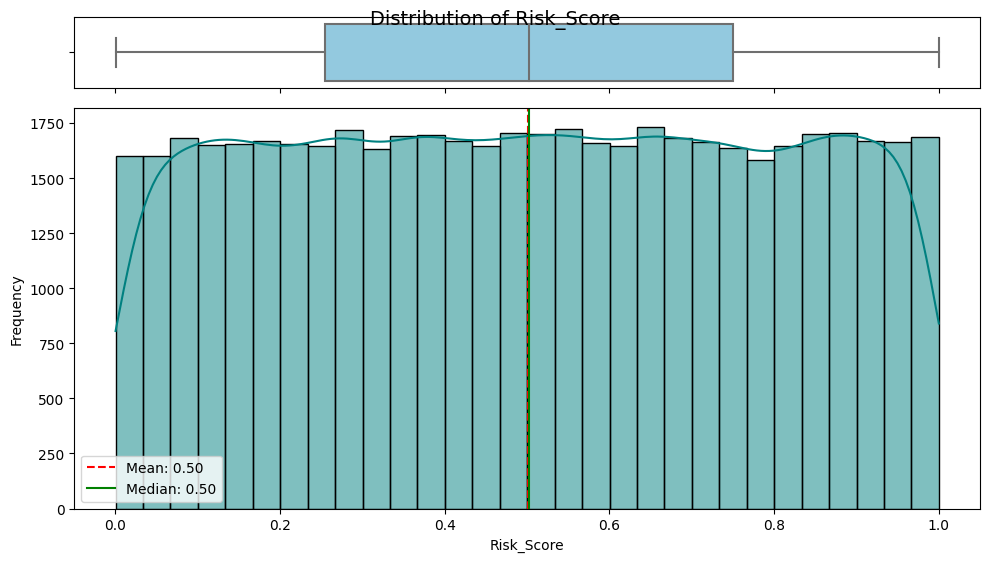

In [40]:
plot_distribution_numeric(dataset, "Risk_Score")

### Is_Weekend

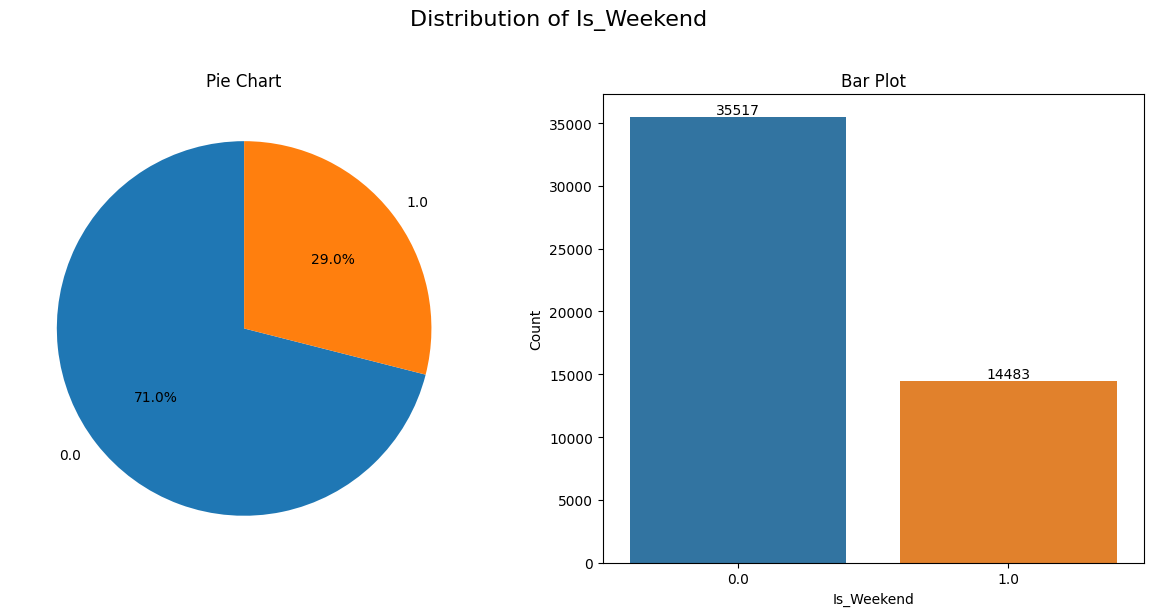

In [41]:
plot_distribution_categorical(dataset, "Is_Weekend")

### Goal variable (Fraud_Label)

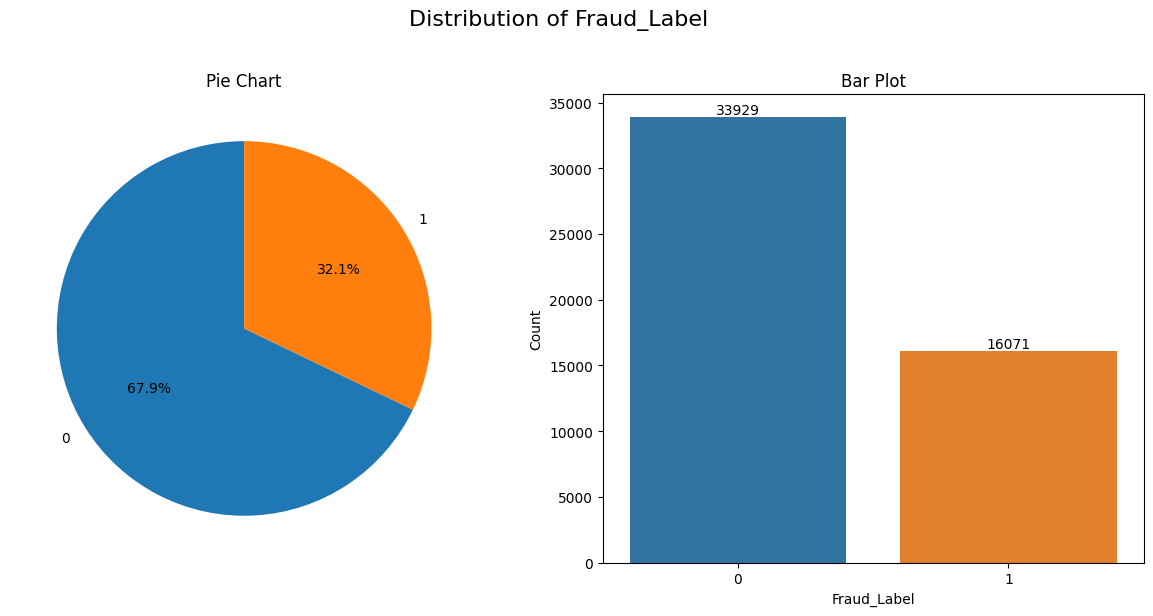

In [42]:
plot_distribution_categorical(dataset, "Fraud_Label")

## Visualizations

### Corerration matrix for numeric features

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


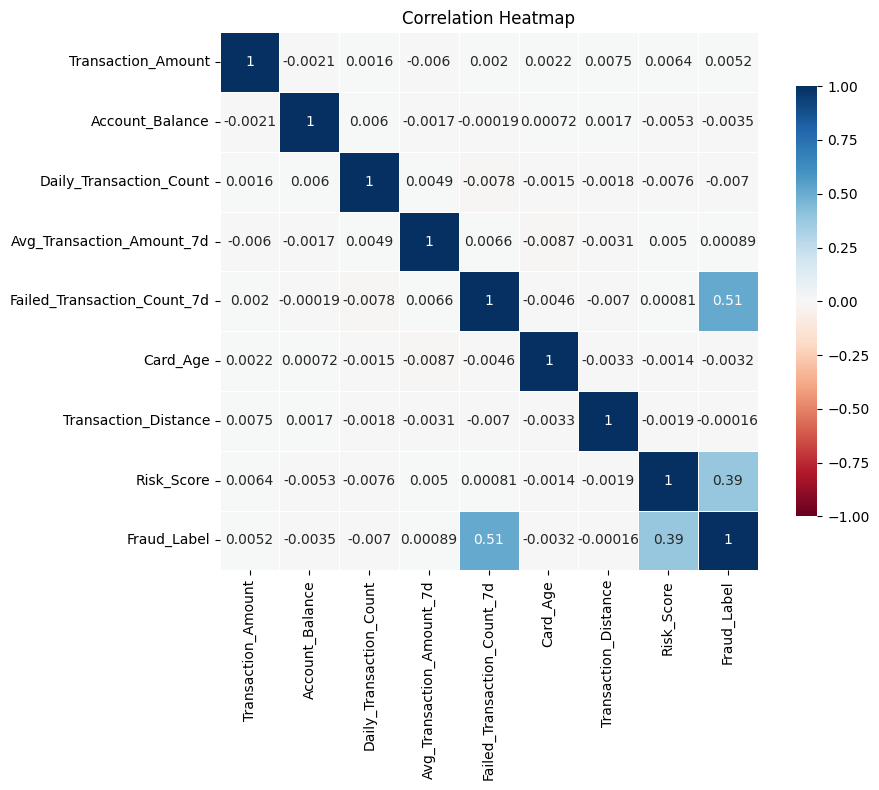

In [43]:
temp = dataset[["Transaction_Amount", "Account_Balance", "Daily_Transaction_Count", "Avg_Transaction_Amount_7d",
               "Failed_Transaction_Count_7d", "Card_Age", "Transaction_Distance", "Risk_Score", "Fraud_Label"]]
plt.figure(figsize=(10, 8))
sns.heatmap(temp.corr(),
            annot=True,
            cmap='RdBu',
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

From the correlation matrix, it can be concluded that only numeric features that correlate with the goal variable are Failed_Transaction_Count_7d and Risk_Score.

### Distributions of numeric features by each fraud label

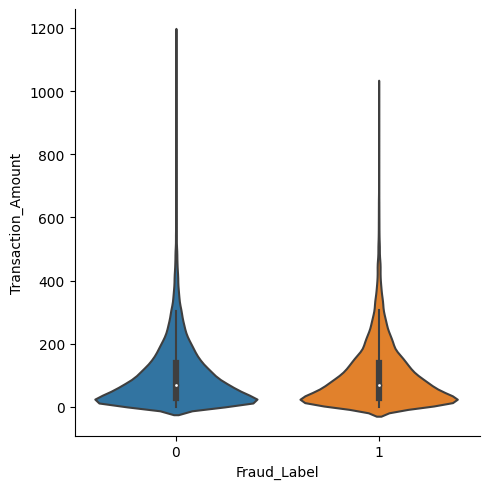

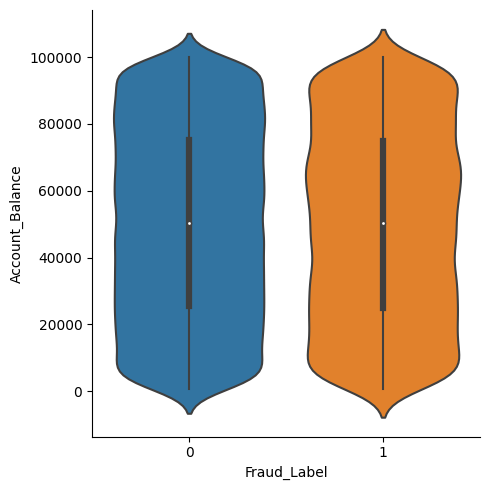

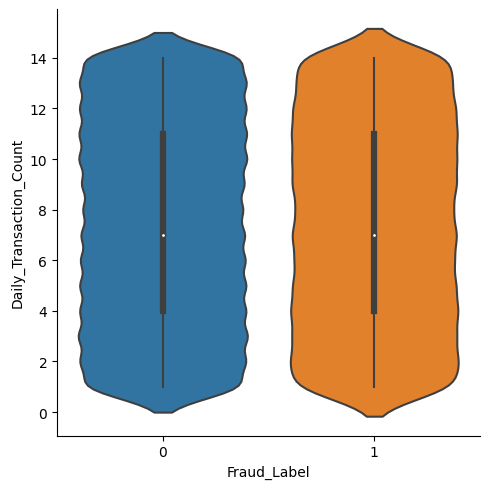

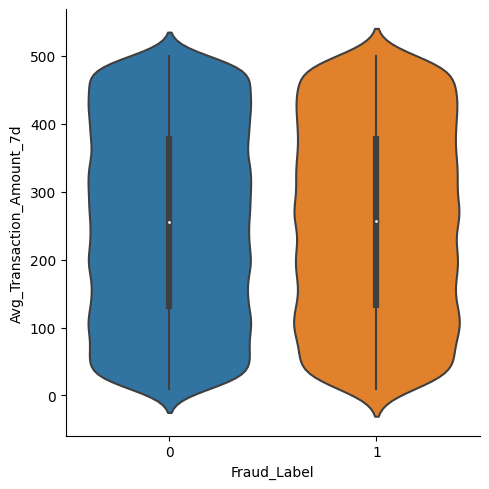

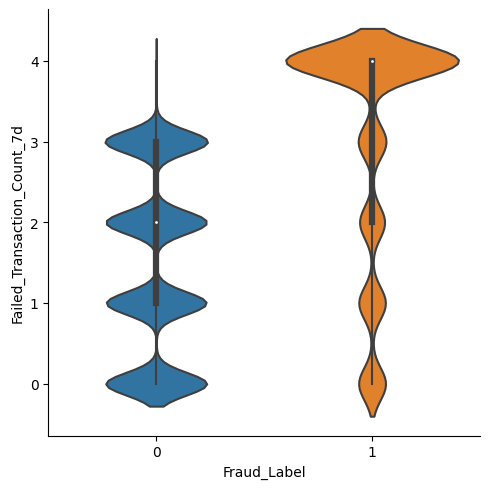

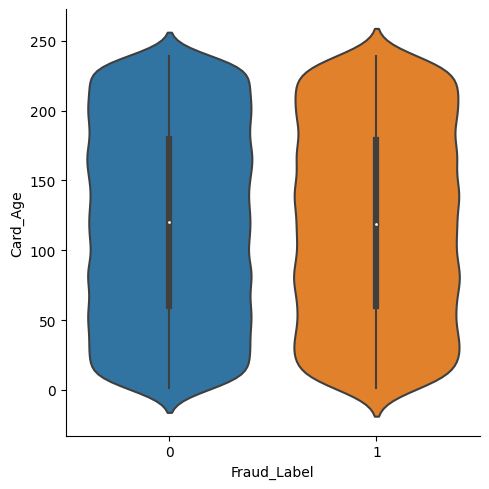

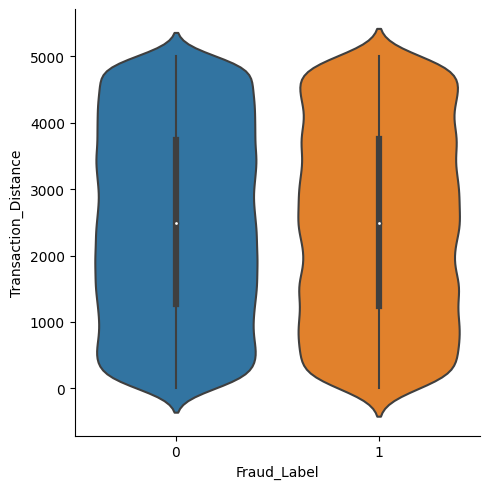

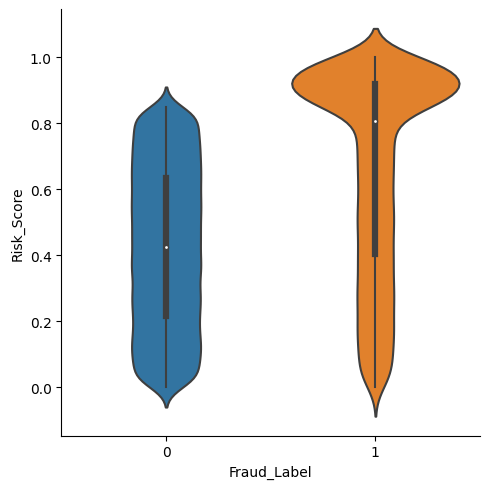

In [44]:
for feature in numeric_to_check:
    sns.catplot(data=dataset, x="Fraud_Label", y=feature, kind="violin")

Only Failed_Transaction_Count_7d and Risk_Score have different distributions for each Fraud_Label which is consistent with the correlation matrix.

### Goal variable class disbalance for categorical features

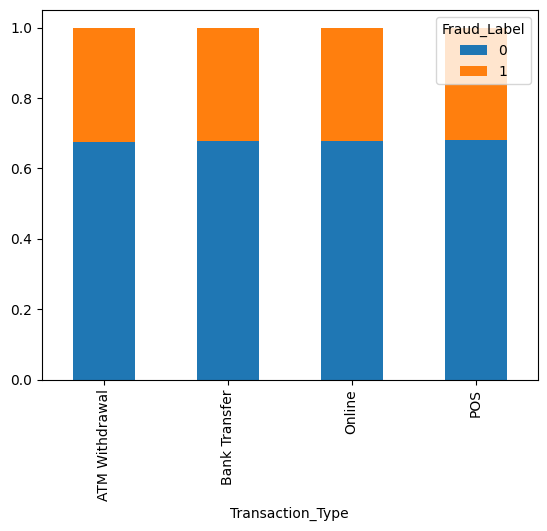

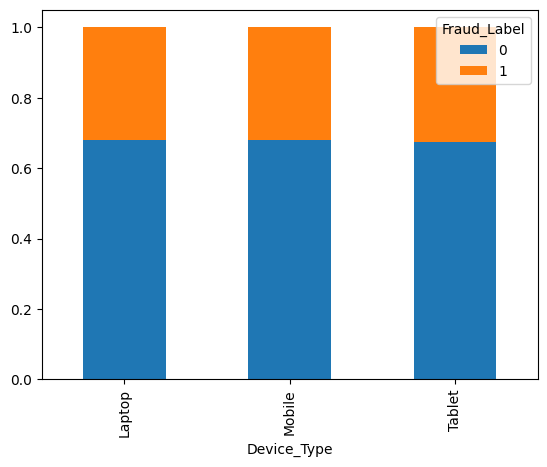

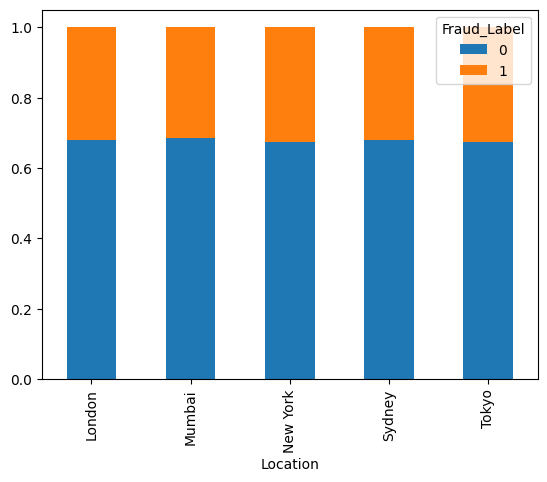

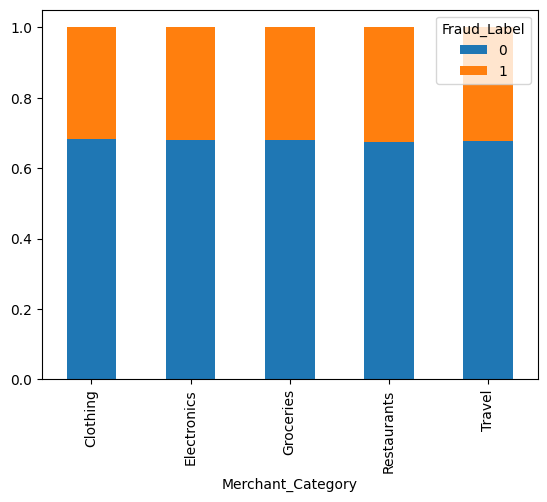

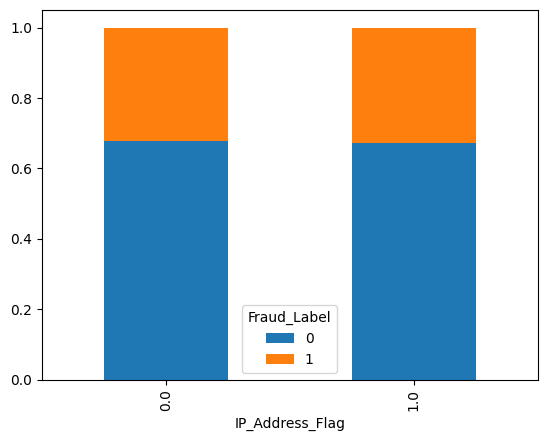

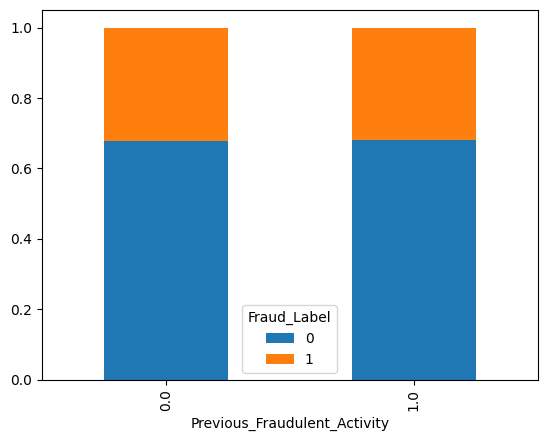

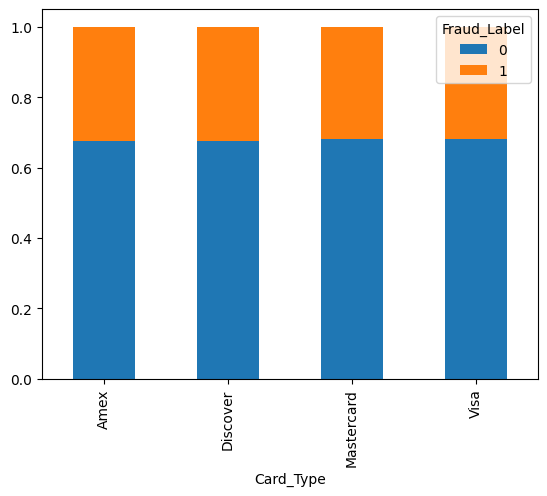

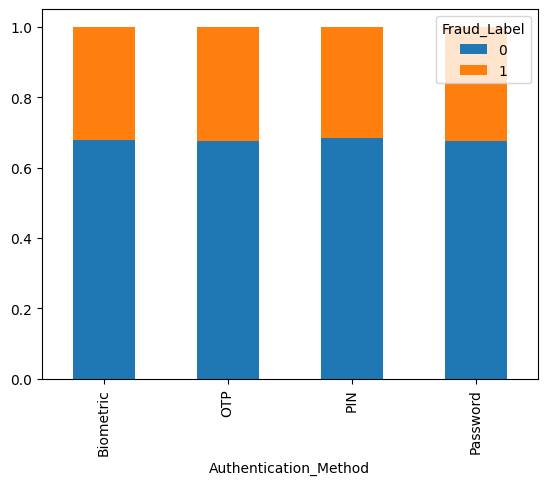

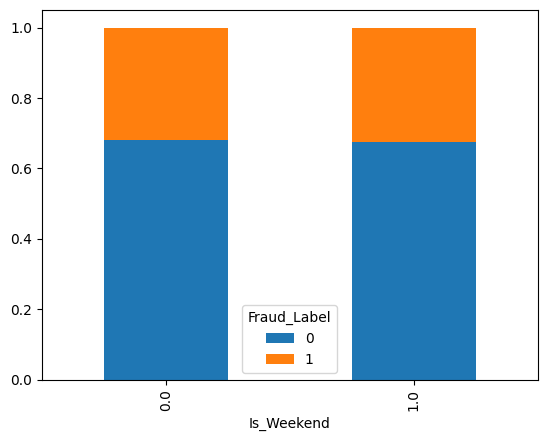

In [45]:
for feature in categorical_to_check:
    if feature == "Fraud_Label":
        continue
    pd.crosstab(dataset[feature], dataset["Fraud_Label"], normalize='index').plot.bar(stacked=True)

### Mean fraud label by values in categorical features

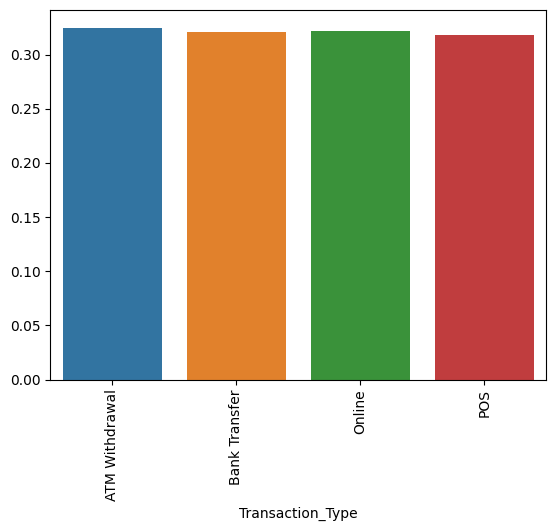

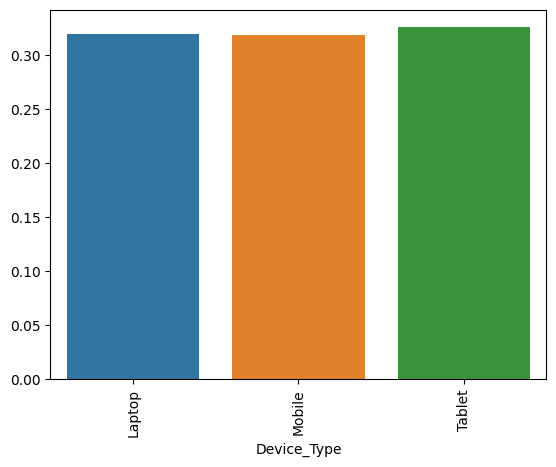

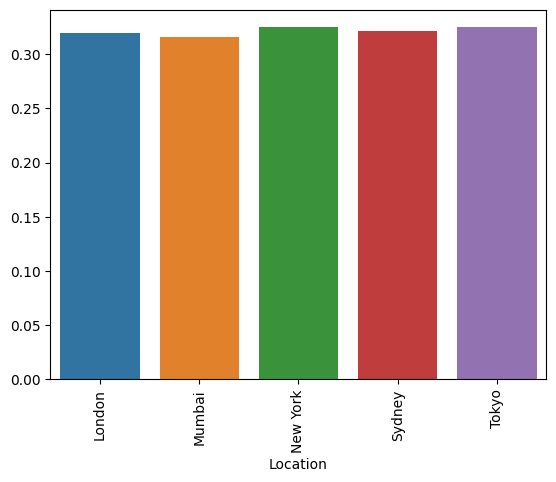

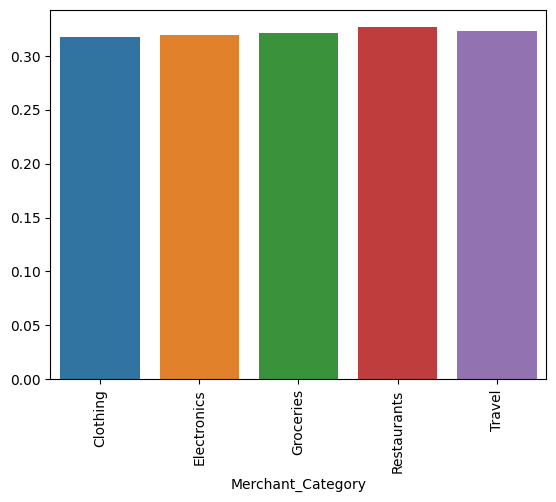

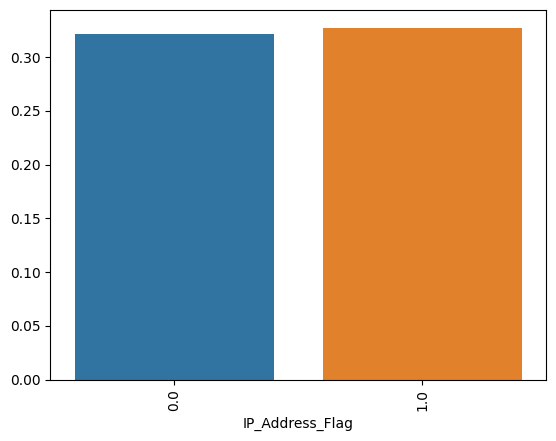

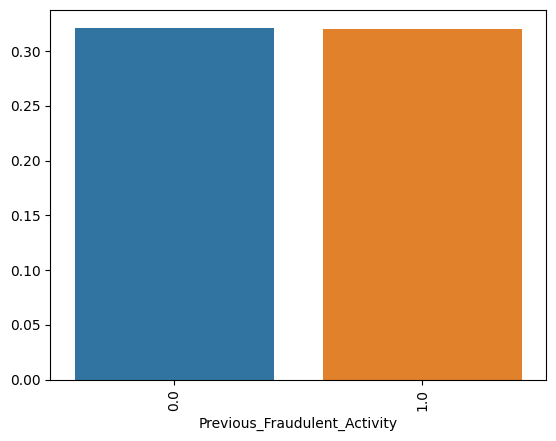

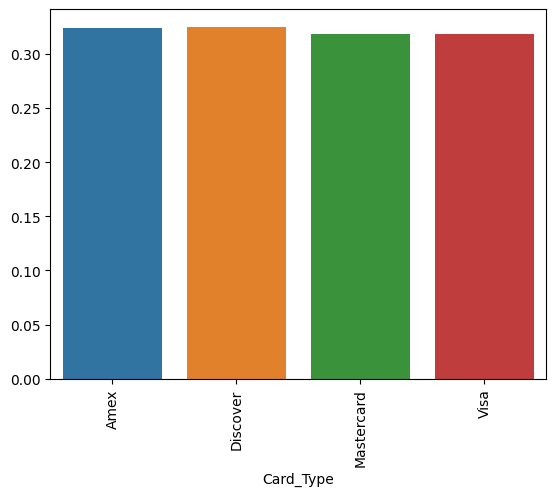

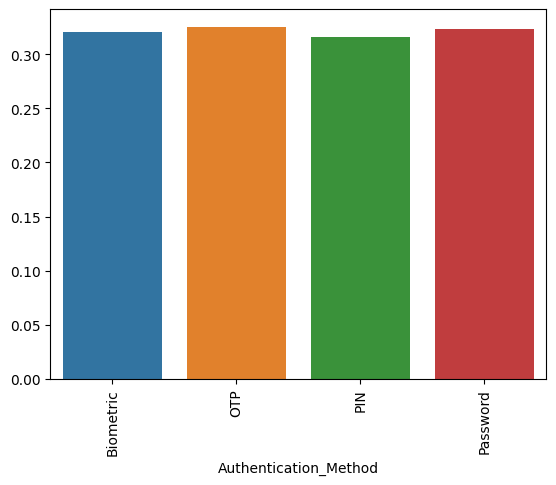

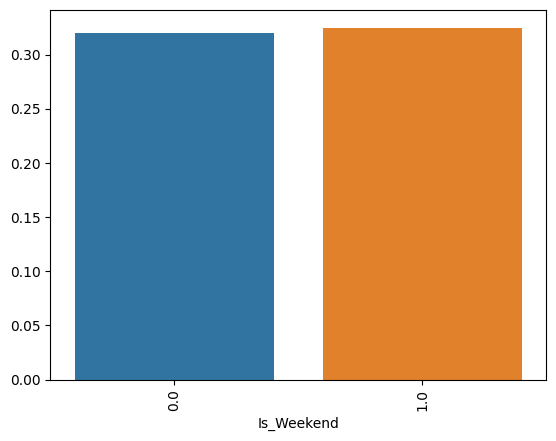

In [46]:
for feature in categorical_to_check:
    if feature == "Fraud_Label":
        continue
    category_risk = dataset.groupby(feature)["Fraud_Label"].mean()
    sns.barplot(x=category_risk.index, y=category_risk.values)
    plt.xticks(rotation=90)
    plt.show()

The graphs show that all categorical features do not have a significant correlation with the goal variable.

##  Date with the biggest amount of fraudulent transactions

In [48]:
dataset = pd.read_csv("/kaggle/input/dap-fer2025/dataset.csv")
dataset['Date'] = pd.to_datetime(dataset['Timestamp']).dt.date

fraud_amounts = dataset[dataset['Fraud_Label'] == 1].groupby('Date')['Transaction_Amount'].sum()

peak_fraud_date = fraud_amounts.idxmax()
peak_fraud_total = fraud_amounts.max()

print(f"Date with highest fraudulent amount: {peak_fraud_date} (Total: ${peak_fraud_total:,.2f})")

Date with highest fraudulent amount: 2023-11-24 (Total: $10,884.44)


November 24, 2023, was Black Friday, a major shopping event that typically sees a surge in both legitimate and fraudulent transactions.